# Caso de estudio: predicción de fraude financiero
## Contexto empresarial: Banco NovaFin
**Banco NovaFin** es un banco digital ficticio que permite solicitar cuentas con acceso a crédito desde su página web y aplicación móvil. Su crecimiento ha incrementado tanto las solicitudes legítimas como los intentos de apertura fraudulenta.

El área de Prevención de Fraude dispone de información del formulario, validación de contacto, dispositivo, sesión y actividad reciente de solicitudes. Actualmente utiliza reglas generales y revisión manual. Revisar todas las solicitudes retrasa la atención; revisar muy pocas deja pasar casos que pueden generar pérdidas.

La gerencia plantea: **¿podemos estimar qué solicitudes tienen mayor riesgo de resultar fraudulentas y priorizar su revisión?**

```text
SOLICITUD COMPLETADA
        ↓
DATOS DISPONIBLES
        ↓
MODELO PREDICTIVO
        ↓
PUNTUACIÓN DE RIESGO        
        ↓
COLA DE REVISIÓN
        ↓                                                                  ↓
DECISIÓN DEL ANALISTA
```

### Rol del alumno
Asumes el rol de **Analista de Datos de Prevención de Fraude de NovaFin**. Utilizarás Python, Pandas, Matplotlib / Seaborn y Scikit-learn para explorar solicitudes, construir clasificadores y proponer una cola de revisión con capacidad limitada.

### Qué vamos a predecir
La unidad de análisis es **una solicitud**, no una persona a lo largo de su vida. La variable `fraud_bool` indica si la solicitud fue etiquetada como fraudulenta. El modelo aprende a estimar ese riesgo al evaluar otra solicitud; no identifica intenciones ni predice la fecha en que alguien cometería un delito.

**Preguntas finales:** ¿hay señal predictiva en solicitudes de meses posteriores?, ¿qué proporción de fraudes captura el 5 % de solicitudes priorizadas?, ¿cuántas solicitudes legítimas se envían a revisión adicional?


## Metodología
- Caso empresarial, preparación sin fuga de información, comparación de modelos, ranking, métricas de capacidad y respuesta ejecutiva.
- Inspección, limpieza documentada, `groupby`, tablas dinámicas, gráficos y recomendación operativa.
- Separar X/y, codificar, escalar, entrenar k-NN, evaluar, predecir una observación y guardar el modelo.

La separación de datos será **temporal**; las categorías se codificarán con `OneHotEncoder`; los nulos se tratarán por tipo; la revisión se evaluará por mes. Para trabajar en un equipo de clase limitamos únicamente el entrenamiento a una muestra estratificada reproducible. Validación y prueba conservan todos sus registros.

El notebook es una solución guiada: contiene código completo, resultados calculados, preguntas de interpretación y una rúbrica. No requiere ejecutar los notebooks anteriores.


## Dataset, procedencia y alcance
Usamos **Base.csv** de [Bank Account Fraud Dataset Suite — NeurIPS 2022 en Kaggle](https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022). Son solicitudes sintéticas generadas a partir de un caso bancario real. Las variantes son experimentos alternativos: **no las concatenamos** como si fueran clientes adicionales.

La [ficha técnica de los autores](https://github.com/feedzai/bank-account-fraud/blob/main/documents/datasheet.pdf) define `fraud_bool`, los marcadores de ausencia y el eje temporal. `month` toma valores 0 a 7: son periodos relativos, no fechas de calendario. El CSV no incluye un identificador real de cliente; crearemos uno técnico a partir de la posición de la fila para rastrear resultados.

Las etiquetas originales se confirmaron meses después de las solicitudes. Nuestra evaluación temporal es **retrospectiva**: no demuestra que todas las etiquetas anteriores ya estuvieran disponibles en cada fecha de entrenamiento. Una evaluación operativa necesitaría fechas de confirmación y ventanas de maduración.

Los autores destinan BAF a experimentación y evaluación de modelos; los artefactos de este caso son **didácticos**. El desempeño sobre BAF no certifica su uso en un banco real. Además, el universo etiquetado original pasó filtros previos de elegibilidad y no representa a todo posible solicitante.

Referencia: Jesus et al. (2022), *Turning the Tables: Biased, Imbalanced, Dynamic Tabular Datasets for ML Evaluation*. [Repositorio de Feedzai](https://github.com/feedzai/bank-account-fraud).


## Preparar el entorno
Ejecuta desde la raíz del proyecto. El archivo descargado se encuentra en:
```text
data/bank_account_fraud/Base.csv
```
Si cambias de equipo, descarga **Base.csv** desde la ficha de Kaggle y conserva ese nombre. No necesitas las cinco variantes ni datos de clientes reales.

Si faltan dependencias, ejecuta en una celda y reinicia el kernel:
```python
%pip install pandas numpy matplotlib seaborn scikit-learn joblib
```
No instalamos paquetes automáticamente al ejecutar el caso. La preparación y las predicciones utilizan el mismo contrato de columnas. Las salidas se escribirán en `exports/fraude_financiero/`.


In [1]:
# 1. Importar librerías y fijar decisiones antes del análisis
from pathlib import Path
import hashlib
import json
import platform
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

SEMILLA = 42
OBJETIVO = 'fraud_bool'
RUTA_DATOS = Path('data/bank_account_fraud')
RUTA_SALIDA = Path('exports/fraude_financiero')
MESES_TRAIN, MESES_VAL, MESES_TEST = [0, 1, 2, 3, 4], [5], [6, 7]
MAX_ENTRENAMIENTO = 100_000  # None usa todos los meses de entrenamiento; k-NN tarda más
FRACCION_REVISION = 0.05     # Política didáctica: revisar el 5 % por mes
UMBRAL_REFERENCIA = 0.50
TAMANO_LOTE = 20_000        # Limita memoria al predecir con k-NN

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 35)
print('Python:', platform.python_version(), '| Scikit-learn:', sklearn.__version__)


Python: 3.11.9 | Scikit-learn: 1.9.0


## Diccionario de trabajo y disponibilidad
Agrupamos los campos por su función. Las categorías anonimizadas se conservarán como códigos: no inventamos el significado de cada letra.

| Familia | Variables que analizaremos |
| --- | --- |
| Coherencia y contacto | `name_email_similarity`, `email_is_free`, `phone_home_valid`, `phone_mobile_valid` |
| Historial de direcciones y relación bancaria | `prev_address_months_count`, `current_address_months_count`, `bank_months_count`, `has_other_cards` |
| Actividad de solicitudes | `zip_count_4w`, `velocity_6h`, `velocity_24h`, `velocity_4w`, `bank_branch_count_8w`, `date_of_birth_distinct_emails_4w` |
| Solicitud y canal | `intended_balcon_amount`, `payment_type`, `proposed_credit_limit`, `source`, `foreign_request`, `housing_status` |
| Sesión y dispositivo | `session_length_in_minutes`, `device_os`, `keep_alive_session`, `device_distinct_emails_8w` |

**Momento de puntuación del caso:** revisión de una solicitud completada, cuando la sesión y sus validaciones están disponibles. Las variables históricas deben calcularse con información anterior a ese momento. La ficha nombra `device_distinct_emails`; en el CSV Base la columna se llama `device_distinct_emails_8w`.

Excluimos `days_since_request` porque refleja tiempo transcurrido después de solicitar; `device_fraud_count` porque requiere comprobar cuándo se confirmaron los fraudes; y `credit_risk_score` para que el primer modelo no dependa de otro sistema de riesgo de disponibilidad no verificada.

`customer_age`, `income` y `employment_status` se reservan para explorar y auditar errores, sin incorporarlos como predictores. `income` está expresado en deciles y `customer_age` por décadas: no son ingreso monetario ni edad exacta. Excluirlos no garantiza ausencia de sesgo; otros atributos pueden actuar como sustitutos.


In [2]:
# 2. Cargar Base.csv y validar el esquema
CATEGORICAS = ['payment_type', 'housing_status', 'source', 'device_os']
NUMERICAS = ['name_email_similarity', 'prev_address_months_count', 'current_address_months_count',
    'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w',
    'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'email_is_free',
    'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards',
    'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes',
    'keep_alive_session', 'device_distinct_emails_8w']
COLUMNAS_ENTRADA = NUMERICAS + CATEGORICAS
AUDITORIA = ['customer_age', 'income', 'employment_status']
EXCLUIDAS = ['days_since_request', 'device_fraud_count', 'credit_risk_score']

ruta_base = RUTA_DATOS / 'Base.csv'
if not ruta_base.exists():
    raise FileNotFoundError(f'Falta {ruta_base.resolve()}. Descarga Base.csv de BAF en Kaggle.')
df_original = pd.read_csv(ruta_base)
df_original.columns = df_original.columns.str.strip()
if df_original.columns.duplicated().any():
    raise ValueError('Hay nombres de columnas repetidos.')
requeridas = set(COLUMNAS_ENTRADA + AUDITORIA + EXCLUIDAS + [OBJETIVO, 'month'])
if requeridas - set(df_original.columns):
    raise ValueError(f'Faltan columnas de Base.csv: {sorted(requeridas - set(df_original.columns))}')
print('Filas y columnas:', df_original.shape)
display(df_original.head())


Filas y columnas: (1000000, 32)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [3]:
# 3. Inspección de calidad: nulos visibles, tipos y duplicados
df_original.info()
calidad_inicial = pd.DataFrame({
    'tipo': df_original.dtypes.astype(str),
    'nulos': df_original.isna().sum(),
    'distintos': df_original.nunique(dropna=True)
})
display(calidad_inicial)

duplicados = int(df_original.duplicated().sum())
print('Filas exactamente duplicadas:', duplicados)

# No hay un ID real que permita decidir si dos solicitudes idénticas son la misma.
# La fuente afirma que no hay duplicados: si aparecen, pedimos revisar la copia de datos.
if duplicados:
    raise ValueError('Se encontraron duplicados inesperados. Revisar Base.csv antes de continuar.')
df = df_original.copy()
df.insert(0, 'solicitud_id', np.arange(1, len(df) + 1))  # Posición técnica; no es un cliente real
for columna, permitidos in [(OBJETIVO, [0, 1]), ('month', list(range(8)))]:
    valores = pd.to_numeric(df[columna], errors='coerce')
    if valores.isna().any() or not valores.isin(permitidos).all():
        raise ValueError(f'Valores inválidos en {columna}.')
    df[columna] = valores.astype(int)
if set(df['month']) != set(range(8)):
    raise ValueError('Este desarrollo espera los ocho meses de Base.csv.')


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  str    
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000000 non-nul

,tipo,nulos,distintos
fraud_bool,int64,0,2
income,float64,0,9
name_email_similarity,float64,0,998861
prev_address_months_count,int64,0,374
current_address_months_count,int64,0,423
customer_age,int64,0,9
days_since_request,float64,0,989330
intended_balcon_amount,float64,0,994971
payment_type,str,0,5
zip_count_4w,int64,0,6306


Filas exactamente duplicadas: 0


## Limpieza con reglas específicas del dataset
Un resultado de cero nulos en `isna()` no significa que el archivo esté completo. Convertiremos **−1 a NaN** en duración de direcciones, antigüedad bancaria, duración de sesión y correos distintos por dispositivo. En `intended_balcon_amount`, **cualquier negativo representa ausencia**.

No aplicamos esa regla a todas las columnas: por ejemplo, la ficha admite valores negativos en `velocity_6h`. Conservamos esos valores sintéticos y documentamos su interpretación limitada. Tampoco eliminamos extremos por un límite estadístico aprendido en todo el archivo.

Las categorías se normalizan con `strip` y mayúsculas. La imputación de números y categorías se aprenderá después, dentro del pipeline y usando solamente entrenamiento.


In [4]:
# 4. Preparación determinista: también se aplicará a solicitudes nuevas
REGLAS_PREPARACION = {
    'entrada': COLUMNAS_ENTRADA, 'numericas': NUMERICAS, 'categoricas': CATEGORICAS,
    'menos_uno_es_nulo': ['prev_address_months_count', 'current_address_months_count',
        'bank_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w'],
    'negativo_es_nulo': ['intended_balcon_amount']
}

def preparar_variables(tabla, reglas=REGLAS_PREPARACION):
    faltantes = set(reglas['entrada']) - set(tabla.columns)
    if faltantes:
        raise ValueError(f'Faltan predictores: {sorted(faltantes)}')
    x = tabla[reglas['entrada']].copy()
    for columna in reglas['numericas']:
        convertido = pd.to_numeric(x[columna], errors='coerce')
        if (x[columna].notna() & convertido.isna()).any():
            raise ValueError(f'Texto no numérico en {columna}; revisar el archivo.')
        x[columna] = convertido.astype(float).replace([np.inf, -np.inf], np.nan)
    for columna in reglas['menos_uno_es_nulo']:
        x[columna] = x[columna].mask(x[columna] == -1)
    for columna in reglas['negativo_es_nulo']:
        x[columna] = x[columna].mask(x[columna] < 0)
    for columna in reglas['categoricas']:
        normalizada = x[columna].astype('string').str.strip().str.upper()
        normalizada = normalizada.mask(normalizada == '')
        x[columna] = normalizada.astype(object).where(normalizada.notna(), np.nan)
    return x

X = preparar_variables(df)
y = df[OBJETIVO]
diagnostico_nulos = pd.DataFrame({
    'nulos_antes': df[COLUMNAS_ENTRADA].isna().sum(),
    'nulos_despues': X.isna().sum(),
    'porcentaje_despues': X.isna().mean() * 100
}).sort_values('porcentaje_despues', ascending=False)
display(diagnostico_nulos.head(10))


,nulos_antes,nulos_despues,porcentaje_despues
intended_balcon_amount,0,742523,74.2523
prev_address_months_count,0,712920,71.2920
bank_months_count,0,253635,25.3635
current_address_months_count,0,4254,0.4254
session_length_in_minutes,0,2015,0.2015
device_distinct_emails_8w,0,359,0.0359
zip_count_4w,0,0,0.0000
name_email_similarity,0,0,0.0000
velocity_4w,0,0,0.0000
velocity_24h,0,0,0.0000


## Separación temporal antes del EDA con etiquetas
| Conjunto | Meses relativos | Uso |
| --- | --- | --- |
| Entrenamiento | 0–4 | EDA, imputación, codificación, escalado y ajuste |
| Validación | 5 | Elección del modelo y punto de corte de referencia |
| Prueba | 6–7 | Evaluación final de la política ya definida |

La ficha propone separar meses tempranos y tardíos; aquí reservamos además un mes para elegir modelo. **No distribuimos filas al azar entre pasado y futuro.** Los meses no son una historia repetida del mismo cliente: BAF no permite reconstruir trayectorias individuales.

Para tiempos de clase usamos hasta 100 000 solicitudes del bloque de entrenamiento, estratificadas por mes y etiqueta. Todos los modelos reciben la misma muestra y se conserva aproximadamente la prevalencia original. No hacemos sobremuestreo ni equilibramos artificialmente las clases. El EDA usa el bloque completo de entrenamiento; las métricas usan todos los registros de validación y prueba.


In [5]:
# 5. Reservar meses y tomar una muestra exclusivamente del entrenamiento
idx_train_total = df.index[df['month'].isin(MESES_TRAIN)]
idx_val = df.index[df['month'].isin(MESES_VAL)]
idx_test = df.index[df['month'].isin(MESES_TEST)]
for indices in [idx_train_total, idx_val, idx_test]:
    if len(indices) == 0 or set(y.loc[indices]) != {0, 1}:
        raise ValueError('Cada partición necesita registros y ambas clases.')

if MAX_ENTRENAMIENTO is not None and len(idx_train_total) > MAX_ENTRENAMIENTO:
    estratos = df.loc[idx_train_total, 'month'].astype(str) + '_' + y.loc[idx_train_total].astype(str)
    idx_train, _ = train_test_split(idx_train_total, train_size=MAX_ENTRENAMIENTO,
                                    stratify=estratos, random_state=SEMILLA)
else:
    idx_train = idx_train_total
X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]
eda = X.loc[idx_train_total].join(df.loc[idx_train_total, [OBJETIVO, 'month'] + AUDITORIA])
display(pd.DataFrame({
    'particion': ['Entrenamiento disponible', 'Entrenamiento utilizado', 'Validación', 'Prueba'],
    'solicitudes': [len(idx_train_total), len(idx_train), len(idx_val), len(idx_test)],
    'meses': ['0–4', '0–4', '5', '6–7']
}))
print(f'Fraude en entrenamiento completo: {y.loc[idx_train_total].mean():.3%}')
print(f'Fraude en la muestra de entrenamiento: {y_train.mean():.3%}')


,particion,solicitudes,meses
0,Entrenamiento disponible,675666,0–4
1,Entrenamiento utilizado,100000,0–4
2,Validación,119323,5
3,Prueba,205011,6–7


Fraude en entrenamiento completo: 0.998%
Fraude en la muestra de entrenamiento: 0.997%


,solicitudes,porcentaje
fraude,,
0,668926,99.002466
1,6740,0.997534


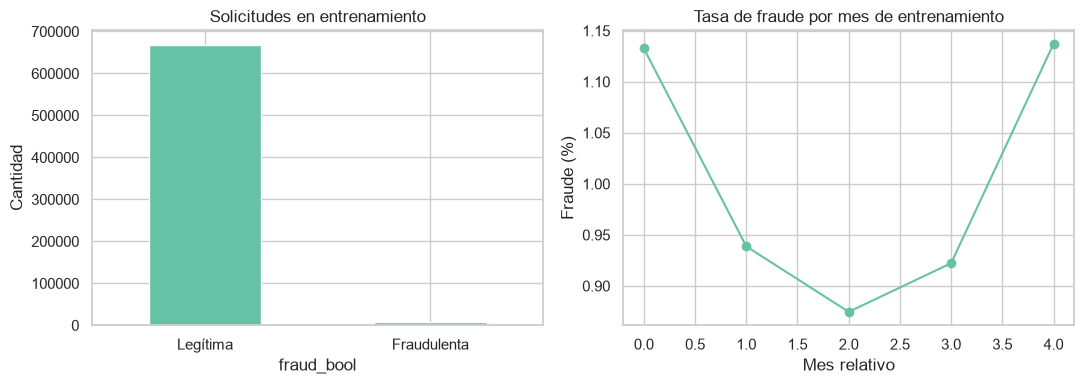

Clasificar todo como legítimo acertaría 99.00%, pero no detectaría ningún fraude.


In [6]:
# 6. Desbalance del objetivo: por qué accuracy no es suficiente
distribucion = eda[OBJETIVO].value_counts().sort_index().rename('solicitudes').to_frame()
distribucion['porcentaje'] = distribucion['solicitudes'] / len(eda) * 100
display(distribucion.rename_axis('fraude'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
distribucion['solicitudes'].rename(index={0: 'Legítima', 1: 'Fraudulenta'}).plot.bar(
    ax=axes[0], rot=0, title='Solicitudes en entrenamiento', ylabel='Cantidad')
eda.groupby('month')[OBJETIVO].mean().mul(100).plot(
    ax=axes[1], marker='o', title='Tasa de fraude por mes de entrenamiento', ylabel='Fraude (%)', xlabel='Mes relativo')
plt.tight_layout()
plt.show()
print(f'Clasificar todo como legítimo acertaría {(eda[OBJETIVO] == 0).mean():.2%}, '
      'pero no detectaría ningún fraude.')


,count,mean,std,min,25%,50%,75%,max,mediana
name_email_similarity,675666.0,0.503432,0.291329,0.000001,0.234754,0.506308,0.767707,0.999999,0.506308
current_address_months_count,672839.0,87.185327,90.859261,0.000000,18.000000,51.000000,131.000000,425.000000,51.000000
bank_months_count,503379.0,14.957406,11.521498,1.000000,1.000000,15.000000,28.000000,32.000000,15.000000
session_length_in_minutes,674388.0,7.948452,8.351392,0.003262,3.407083,5.327003,9.170931,85.899143,5.327003
proposed_credit_limit,675666.0,533.868568,506.482887,190.000000,200.000000,200.000000,990.000000,2100.000000,200.000000
device_distinct_emails_8w,675390.0,1.023395,0.193918,0.000000,1.000000,1.000000,1.000000,2.000000,1.000000


,name_email_similarity,current_address_months_count,bank_months_count,session_length_in_minutes,proposed_credit_limit,device_distinct_emails_8w
fraud_bool,,,,,,
0,0.507319,51.0,15.0,5.327283,200.0,1.0
1,0.314872,93.0,20.0,5.304688,500.0,1.0


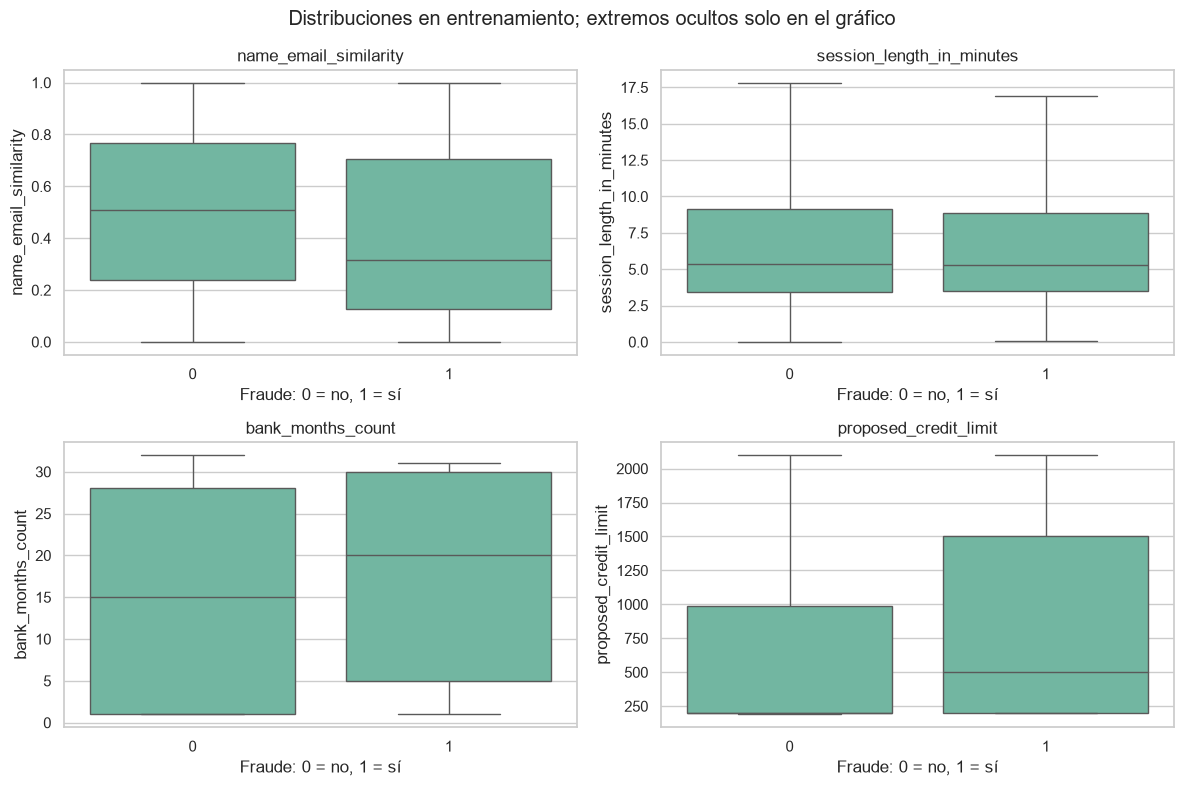

In [7]:
# 7. Estadísticos y perfil de solicitudes por etiqueta
campos_perfil = ['name_email_similarity', 'current_address_months_count', 'bank_months_count',
                  'session_length_in_minutes', 'proposed_credit_limit', 'device_distinct_emails_8w']
estadisticos = eda[campos_perfil].describe().T
estadisticos['mediana'] = eda[campos_perfil].median()
display(estadisticos)
display(eda.groupby(OBJETIVO)[campos_perfil].median())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, columna in zip(axes.flat, ['name_email_similarity', 'session_length_in_minutes',
                                  'bank_months_count', 'proposed_credit_limit']):
    sns.boxplot(data=eda, x=OBJETIVO, y=columna, showfliers=False, ax=ax)
    ax.set(xlabel='Fraude: 0 = no, 1 = sí', title=columna)
plt.suptitle('Distribuciones en entrenamiento; extremos ocultos solo en el gráfico')
plt.tight_layout()
plt.show()


,solicitudes,fraudes,tasa_fraude
source,,,
INTERNET,670596,6667,0.009942
TELEAPP,5070,73,0.014398


,solicitudes,fraudes,tasa_fraude
device_os,,,
WINDOWS,182429,4096,0.022453
MACINTOSH,35809,431,0.012036
X11,4961,53,0.010683
OTHER,220215,1150,0.005222
LINUX,232252,1010,0.004349


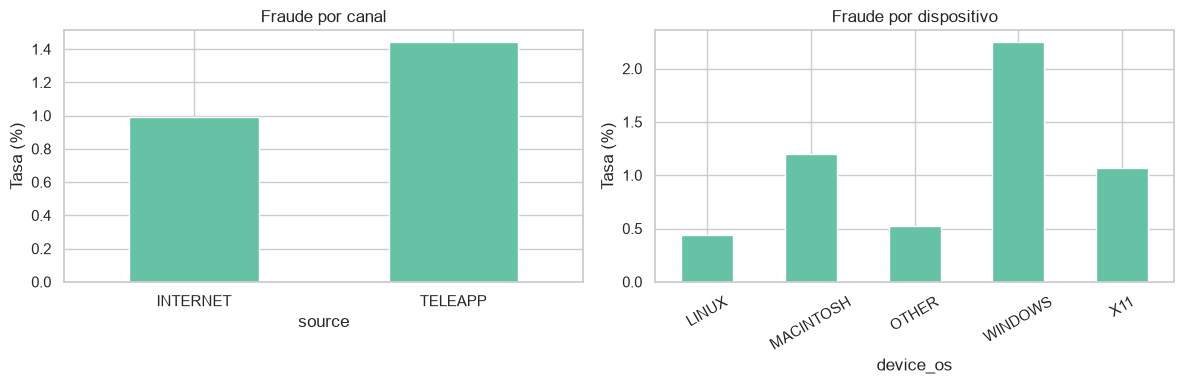

In [8]:
# 8. Agrupaciones por canal y dispositivo, con tamaños y tasas
por_canal = eda.groupby('source', dropna=False).agg(
    solicitudes=(OBJETIVO, 'size'), fraudes=(OBJETIVO, 'sum'), tasa_fraude=(OBJETIVO, 'mean'))
por_dispositivo = eda.groupby('device_os', dropna=False).agg(
    solicitudes=(OBJETIVO, 'size'), fraudes=(OBJETIVO, 'sum'), tasa_fraude=(OBJETIVO, 'mean'))
display(por_canal)
display(por_dispositivo.sort_values('tasa_fraude', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
por_canal['tasa_fraude'].mul(100).plot.bar(ax=axes[0], rot=0, title='Fraude por canal', ylabel='Tasa (%)')
por_dispositivo['tasa_fraude'].mul(100).plot.bar(ax=axes[1], rot=30, title='Fraude por dispositivo', ylabel='Tasa (%)')
plt.tight_layout()
plt.show()


source,INTERNET,TELEAPP
month,,
0,131685,755
1,126554,1066
2,136277,702
3,149676,1260
4,126404,1287


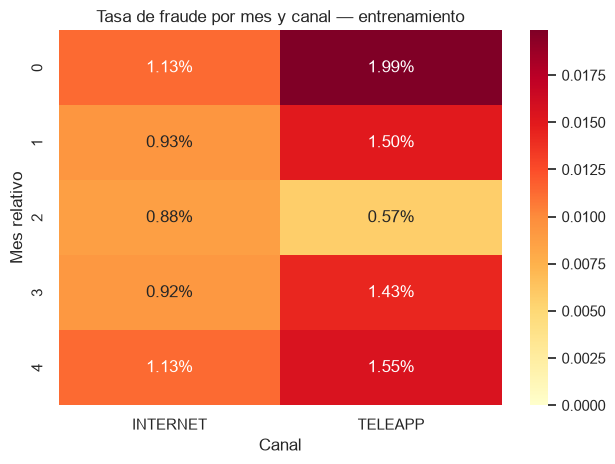

In [ ]:
# 9. Tabla dinámica: mes y canal
tabla_tasas = eda.pivot_table(index='month', columns='source', values=OBJETIVO, aggfunc='mean')
tabla_cantidades = eda.pivot_table(index='month', columns='source', values=OBJETIVO, aggfunc='size')
display(tabla_cantidades)
sns.heatmap(tabla_tasas, annot=True, fmt='.2%', cmap='YlOrRd', vmin=0)
plt.title('Tasa de fraude por mes y canal — entrenamiento')
plt.xlabel('Canal')
plt.ylabel('Mes relativo')
plt.tight_layout()
plt.show()


,solicitudes,fraudes,tasa_fraude
similitud_grupo,,,
Hasta 0.25,177566,2996,0.016873
0.25 a 0.75,315674,2352,0.007451
Más de 0.75,182426,1392,0.007630


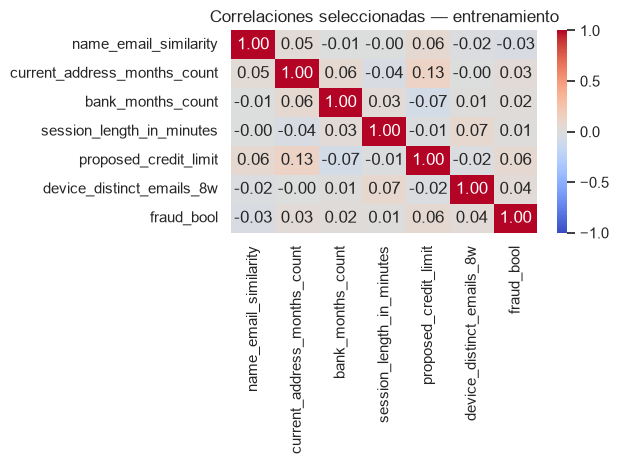

In [10]:
# 10. Relacionar coherencia de contacto con la etiqueta
eda['similitud_grupo'] = pd.cut(eda['name_email_similarity'], bins=[-np.inf, 0.25, 0.75, np.inf],
                               labels=['Hasta 0.25', '0.25 a 0.75', 'Más de 0.75'])
por_similitud = eda.groupby('similitud_grupo', observed=True).agg(
    solicitudes=(OBJETIVO, 'size'), fraudes=(OBJETIVO, 'sum'), tasa_fraude=(OBJETIVO, 'mean'))
display(por_similitud)
correlaciones = eda[campos_perfil + [OBJETIVO]].corr()
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlaciones seleccionadas — entrenamiento')
plt.tight_layout()
plt.show()


In [11]:
# 11. Lectura guiada con cifras calculadas
similitud_mediana = eda.groupby(OBJETIVO)['name_email_similarity'].median()
canal_mayor = por_canal['tasa_fraude'].idxmax()
display(Markdown(f'''### Hallazgos del EDA
1. El bloque de entrenamiento tiene **{len(eda):,} solicitudes** y una tasa de fraude de
   **{eda[OBJETIVO].mean():.2%}**. La clase minoritaria exige medir los fraudes detectados.
2. La mediana de similitud entre nombre y correo es **{similitud_mediana.loc[0]:.3f}** en solicitudes
   legítimas y **{similitud_mediana.loc[1]:.3f}** en fraudulentas. Es una asociación del dataset.
3. El canal con mayor tasa observada es **{canal_mayor}**, con **{por_canal.loc[canal_mayor, 'tasa_fraude']:.2%}**
   sobre **{por_canal.loc[canal_mayor, 'solicitudes']:,.0f} solicitudes**. La tasa debe leerse junto al tamaño del grupo.

Estos resultados no establecen causas ni justifican rechazar automáticamente una solicitud por pertenecer a un grupo.
'''))


### Hallazgos del EDA
1. El bloque de entrenamiento tiene **675,666 solicitudes** y una tasa de fraude de
   **1.00%**. La clase minoritaria exige medir los fraudes detectados.
2. La mediana de similitud entre nombre y correo es **0.507** en solicitudes
   legítimas y **0.315** en fraudulentas. Es una asociación del dataset.
3. El canal con mayor tasa observada es **TELEAPP**, con **1.44%**
   sobre **5,070 solicitudes**. La tasa debe leerse junto al tamaño del grupo.

Estos resultados no establecen causas ni justifican rechazar automáticamente una solicitud por pertenecer a un grupo.


### Preguntas para el alumno
¿Qué diferencia hay entre contar fraudes y calcular una tasa? ¿En qué meses cambian los patrones? ¿Qué información falta para asegurar que una variable estaba disponible al revisar la solicitud? Explica dos hallazgos y una limitación con apoyo de las tablas.

## Preparar X e y: modelos con variables numéricas y categóricas
El `ColumnTransformer` aplica un tratamiento por tipo:
- Numéricas: mediana del entrenamiento, indicadores de ausencia y `StandardScaler`.
- Categóricas: categoría explícita para ausencia y `OneHotEncoder(handle_unknown='ignore')`.

One-hot crea columnas 0/1 por categoría sin inventar un orden entre códigos. Si aparece una categoría nueva, se puede predecir, pero debe revisarse como cambio de datos. La imputación, las categorías y el escalado se ajustan solo con `X_train`.


In [12]:
# 12. Construir pipelines independientes para cada modelo
numericas_modelo = [c for c in NUMERICAS if X_train[c].nunique(dropna=True) > 1]
categoricas_modelo = [c for c in CATEGORICAS if X_train[c].nunique(dropna=True) > 1]
print('Columnas constantes o vacías excluidas del ajuste:',
      sorted(set(COLUMNAS_ENTRADA) - set(numericas_modelo + categoricas_modelo)))
if not numericas_modelo or not categoricas_modelo:
    raise ValueError('Revisar el esquema o la muestra de entrenamiento.')

def construir_pipeline(clasificador):
    numerico = Pipeline([
        ('imputacion', SimpleImputer(strategy='median', add_indicator=True)),
        ('escalado', StandardScaler())
    ])
    categorico = Pipeline([
        ('imputacion', SimpleImputer(strategy='constant', fill_value='SIN_DATO')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preparacion = ColumnTransformer([
        ('numerico', numerico, numericas_modelo),
        ('categorico', categorico, categoricas_modelo)
    ], remainder='drop')
    return Pipeline([('preparacion', preparacion), ('clasificador', clasificador)])

modelos = {
    'Dummy': construir_pipeline(DummyClassifier(strategy='prior')),
    'k-NN': construir_pipeline(KNeighborsClassifier(n_neighbors=5, n_jobs=4)),
    'Regresión logística': construir_pipeline(LogisticRegression(max_iter=2000, random_state=SEMILLA)),
    'Árbol de decisión': construir_pipeline(DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=200, random_state=SEMILLA))
}


Columnas constantes o vacías excluidas del ajuste: []


## Entrenar y comparar modelos
**Dummy** aprende únicamente la frecuencia de las clases. **k-NN** recupera los cinco vecinos más cercanos. **Regresión logística** ofrece un modelo lineal de referencia como en TelcoNova. **Árbol de decisión** añade reglas no lineales y limita profundidad y tamaño de hojas para reducir sobreajuste.

La configuración está fijada antes de abrir la prueba. No buscamos decenas de combinaciones ni seleccionamos modelos por accuracy. El criterio es **Recall@K en validación**, con K igual al 5 % de solicitudes; ante empate, usamos Average Precision.

| Métrica | Interpretación para NovaFin |
| --- | --- |
| Precision | Proporción de alertas que son fraude |
| Recall | Proporción de todos los fraudes que detectamos |
| F1 | Equilibrio de precision y recall en un punto de corte |
| FPR | Proporción de solicitudes legítimas enviadas a revisión |
| ROC-AUC | Capacidad de ordenar clases a través de distintos umbrales |
| Average Precision (AP) | Resumen de precisión–recall; comparar con la prevalencia |
| Precision@K / Recall@K | Calidad y cobertura de los K casos prioritarios |
| Lift@K | Precision@K dividida por la tasa general de fraude |

Los modelos producen una **puntuación de riesgo estimada**. No verificamos calibración: una puntuación de 0.80 no debe comunicarse como una frecuencia garantizada del 80 %.


In [13]:
# 13. Ranking reproducible y métricas de revisión
def predecir_por_lotes(modelo, datos):
    posicion_fraude = list(modelo.classes_).index(1)
    bloques = [modelo.predict_proba(datos.iloc[i:i + TAMANO_LOTE])[:, posicion_fraude]
               for i in range(0, len(datos), TAMANO_LOTE)]
    return np.concatenate(bloques)

def crear_ranking(ids, meses, probabilidades, etiquetas=None, fraccion=FRACCION_REVISION):
    if not 0 < fraccion <= 1:
        raise ValueError('Fracción fuera de rango.')
    ranking = pd.DataFrame({'solicitud_id': np.asarray(ids), 'month': np.asarray(meses),
                            'riesgo_estimado': np.asarray(probabilidades)})
    if etiquetas is not None:
        ranking['fraude_real'] = np.asarray(etiquetas)
    ranking = ranking.sort_values(['month', 'riesgo_estimado', 'solicitud_id'],
                                   ascending=[True, False, True]).reset_index(drop=True)
    ranking['prioridad_mes'] = ranking.groupby('month').cumcount() + 1
    ranking['cupo_mes'] = np.ceil(ranking.groupby('month')['solicitud_id'].transform('size') * fraccion).astype(int)
    ranking['revisar'] = ranking['prioridad_mes'] <= ranking['cupo_mes']
    return ranking

def resumir_revision(ranking):
    reales = ranking['fraude_real']
    seleccionados = ranking['revisar']
    k = int(seleccionados.sum())
    capturados = int(reales[seleccionados].sum())
    total_fraudes = int(reales.sum())
    legitimas = int((reales == 0).sum())
    precision_k = capturados / k if k else np.nan
    # Referencia aleatoria con el mismo cupo dentro de cada mes.
    azar = sum(grupo['revisar'].sum() * grupo['fraude_real'].mean()
               for _, grupo in ranking.groupby('month'))
    return {'solicitudes': len(ranking), 'revisiones': k, 'fraudes_capturados': capturados,
            'fraudes_totales': total_fraudes, 'legitimas_revisadas': k - capturados,
            'precision_top': precision_k,
            'recall_top': capturados / total_fraudes if total_fraudes else np.nan,
            'fpr_top': (k - capturados) / legitimas if legitimas else np.nan,
            'lift_top': precision_k / reales.mean() if reales.mean() else np.nan,
            'fraudes_esperados_azar': float(azar)}

def metricas_clasificacion(y_real, probabilidades, umbral):
    pred = (np.asarray(probabilidades) >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_real, pred, labels=[0, 1]).ravel()
    return {'accuracy': accuracy_score(y_real, pred),
            'precision': precision_score(y_real, pred, zero_division=0),
            'recall': recall_score(y_real, pred, zero_division=0),
            'f1': f1_score(y_real, pred, zero_division=0),
            'fpr': fp / (tn + fp) if tn + fp else np.nan,
            'roc_auc': roc_auc_score(y_real, probabilidades),
            'average_precision': average_precision_score(y_real, probabilidades),
            'tasa_alertas': float(pred.mean())}


In [14]:
# 14. Ajustar con la misma muestra y comparar sobre TODO el mes de validación
resultados_val = []
probabilidades_val = {}
for nombre, modelo in modelos.items():
    inicio = time.perf_counter()
    print('Entrenando y validando:', nombre, flush=True)
    modelo.fit(X_train, y_train)
    probabilidades = predecir_por_lotes(modelo, X_val)
    probabilidades_val[nombre] = probabilidades
    ranking_val = crear_ranking(df.loc[idx_val, 'solicitud_id'], df.loc[idx_val, 'month'],
                                 probabilidades, y_val)
    resultados_val.append({'modelo': nombre,
        **metricas_clasificacion(y_val, probabilidades, UMBRAL_REFERENCIA),
        **resumir_revision(ranking_val),
        'segundos': time.perf_counter() - inicio})

comparacion = pd.DataFrame(resultados_val).set_index('modelo')
display(comparacion[['accuracy', 'recall', 'average_precision', 'roc_auc',
                     'precision_top', 'recall_top', 'fpr_top', 'lift_top', 'segundos']].round(4))


Entrenando y validando: Dummy
Entrenando y validando: k-NN
Entrenando y validando: Regresión logística
Entrenando y validando: Árbol de decisión


,accuracy,recall,average_precision,roc_auc,precision_top,recall_top,fpr_top,lift_top,segundos
modelo,,,,,,,,,
Dummy,0.9882,0.0000,0.0118,0.5000,0.0137,0.0581,0.0499,1.1621,0.6088
k-NN,0.9881,0.0064,0.0299,0.5892,0.0523,0.2211,0.0480,4.4218,8.0488
Regresión logística,0.9882,0.0028,0.1460,0.8727,0.1119,0.4734,0.0449,9.4671,0.7110
Árbol de decisión,0.9882,0.0000,0.0760,0.7997,0.0868,0.3671,0.0462,7.3413,1.1990


In [15]:
# 15. Elegir modelo y congelar un umbral antes de abrir la prueba
orden = comparacion.drop(index='Dummy').sort_values(['recall_top', 'average_precision'], ascending=False)
nombre_elegido = orden.index[0]
modelo_elegido = modelos[nombre_elegido]
ranking_validacion = crear_ranking(df.loc[idx_val, 'solicitud_id'], df.loc[idx_val, 'month'],
                                    probabilidades_val[nombre_elegido], y_val)

umbral_validacion = float(ranking_validacion.loc[ranking_validacion['revisar'], 'riesgo_estimado'].min())
print('Modelo elegido:', nombre_elegido)
print(f'Umbral de referencia aprendido en validación: {umbral_validacion:.6f}')
print('El cupo exacto se aplica por ranking; un umbral puede superarlo por empates o cambios mensuales.')
if orden.iloc[0]['lift_top'] <= 1:
    print('Validación sin mejora frente a la tasa base: no recomendar uso operativo.')


Modelo elegido: Regresión logística
Umbral de referencia aprendido en validación: 0.030274
El cupo exacto se aplica por ranking; un umbral puede superarlo por empates o cambios mensuales.


## Interpretar el modelo y los puntos de corte
El ranking con cupo y el umbral responden a preguntas diferentes. El primero selecciona exactamente K solicitudes de un lote mensual; el segundo permite puntuar una solicitud aislada, pero su volumen de alertas puede cambiar en otro mes.

Mostramos coeficientes logísticos como explicación de esa alternativa, incluso si gana otro modelo. Un coeficiente describe una asociación condicionada al resto de atributos; no identifica una causa ni un motivo individual de fraude. Las variables numéricas están estandarizadas y las categorías se expresan mediante columnas 0/1.


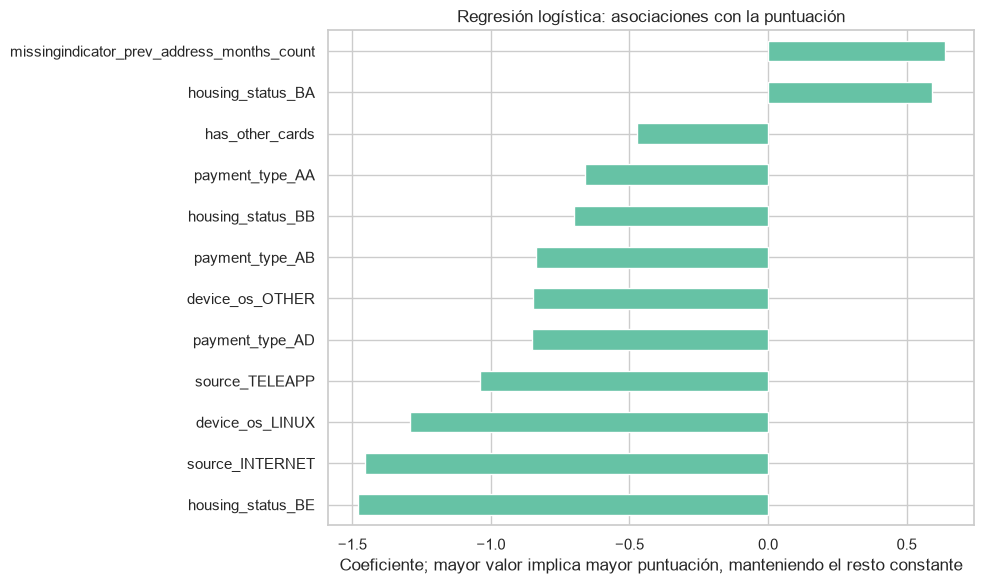

In [16]:
# 16. Coeficientes de la alternativa logística
pipeline_logistico = modelos['Regresión logística']
nombres = pipeline_logistico.named_steps['preparacion'].get_feature_names_out()
coeficientes = pd.Series(pipeline_logistico.named_steps['clasificador'].coef_[0], index=nombres)
principales = coeficientes.loc[coeficientes.abs().nlargest(12).index].sort_values()
principales.index = principales.index.str.replace('numerico__', '', regex=False).str.replace('categorico__', '', regex=False)
principales.plot.barh(figsize=(10, 6), title='Regresión logística: asociaciones con la puntuación')
plt.xlabel('Coeficiente; mayor valor implica mayor puntuación, manteniendo el resto constante')
plt.tight_layout()
plt.show()


## Evaluación final: meses 6 y 7
Abrimos la prueba después de fijar modelo, cupo y umbral. No utilizaremos este resultado para volver a elegir modelo o cambiar el 5 %. Comparamos el umbral convencional 0.50 con el aprendido en validación y luego medimos la política de revisión por ranking.

Un **falso positivo** es una solicitud legítima enviada a revisión; un **falso negativo**, una solicitud fraudulenta no detectada. Revisar no equivale a rechazar: el analista reúne evidencia antes de decidir.


,umbral,accuracy,precision,recall,f1,fpr,roc_auc,average_precision,tasa_alertas
politica,,,,,,,,,
Umbral convencional,0.5000,0.9860,0.5000,0.0010,0.0021,0.0000,0.8707,0.1506,0.0000
Umbral de validación,0.0303,0.9503,0.1303,0.4472,0.2018,0.0425,0.8707,0.1506,0.0482


              precision    recall  f1-score   support

    Legítima       0.99      0.96      0.97    202133
 Fraudulenta       0.13      0.45      0.20      2878

    accuracy                           0.95    205011
   macro avg       0.56      0.70      0.59    205011
weighted avg       0.98      0.95      0.96    205011



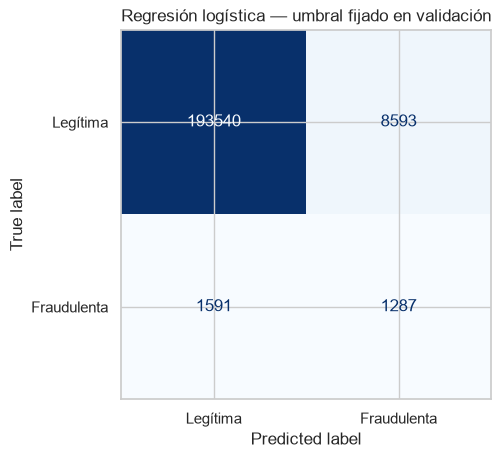

In [17]:
# 17. Métricas de prueba con ambos umbrales
prob_test = predecir_por_lotes(modelo_elegido, X_test)
metricas_test = metricas_clasificacion(y_test, prob_test, umbral_validacion)
comparacion_umbrales = pd.DataFrame([
    {'politica': 'Umbral convencional', 'umbral': UMBRAL_REFERENCIA,
     **metricas_clasificacion(y_test, prob_test, UMBRAL_REFERENCIA)},
    {'politica': 'Umbral de validación', 'umbral': umbral_validacion, **metricas_test}
]).set_index('politica')
display(comparacion_umbrales.round(4))
pred_test = (prob_test >= umbral_validacion).astype(int)
print(classification_report(y_test, pred_test, labels=[0, 1],
                            target_names=['Legítima', 'Fraudulenta'], zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=[0, 1],
    display_labels=['Legítima', 'Fraudulenta'], cmap='Blues', colorbar=False)
plt.title(f'{nombre_elegido} — umbral fijado en validación')
plt.show()


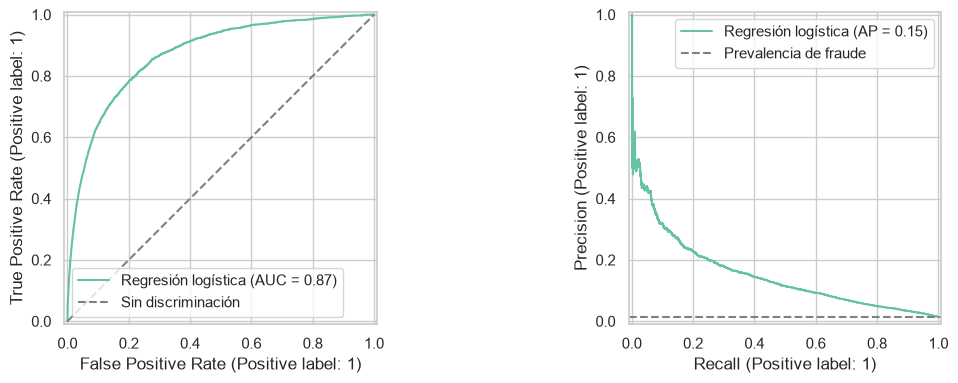

In [18]:
# 18. Curvas de discriminación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, prob_test, name=nombre_elegido, ax=axes[0])
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Sin discriminación')
axes[0].legend()
PrecisionRecallDisplay.from_predictions(y_test, prob_test, name=nombre_elegido, ax=axes[1])
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', label='Prevalencia de fraude')
axes[1].legend()
plt.tight_layout()
plt.show()


In [19]:
# 19. Revisar el 5 % por mes, con desempate por ID técnico
ranking_prueba = crear_ranking(df.loc[idx_test, 'solicitud_id'], df.loc[idx_test, 'month'], prob_test, y_test)
resumen_prueba = resumir_revision(ranking_prueba)
resultados_mes = pd.DataFrame([
    {'month': mes, **resumir_revision(grupo)} for mes, grupo in ranking_prueba.groupby('month')
]).set_index('month')
display(resultados_mes.round(4))
display(pd.Series(resumen_prueba, name='Total prueba').to_frame().round(4))
display(ranking_prueba.loc[ranking_prueba['revisar']].groupby('month').head(5))


,solicitudes,revisiones,fraudes_capturados,fraudes_totales,legitimas_revisadas,precision_top,recall_top,fpr_top,lift_top,fraudes_esperados_azar
month,,,,,,,,,,
6,108168,5409,638,1450,4771,0.1180,0.4400,0.0447,8.7990,72.5080
7,96843,4843,677,1428,4166,0.1398,0.4741,0.0437,9.4801,71.4125


,Total prueba
solicitudes,205011.0000
revisiones,10252.0000
fraudes_capturados,1315.0000
fraudes_totales,2878.0000
legitimas_revisadas,8937.0000
precision_top,0.1283
recall_top,0.4569
fpr_top,0.0442
lift_top,9.1370
fraudes_esperados_azar,143.9206


,solicitud_id,month,riesgo_estimado,fraude_real,prioridad_mes,cupo_mes,revisar
0,902017,6,0.587747,1,1,5409,True
1,867255,6,0.573157,0,2,5409,True
2,850107,6,0.533984,1,3,5409,True
3,851343,6,0.529993,0,4,5409,True
4,805265,6,0.505582,0,5,5409,True
108168,938292,7,0.591206,1,1,4843,True
108169,948909,7,0.458840,1,2,4843,True
108170,941972,7,0.444125,1,3,4843,True
108171,937783,7,0.432482,1,4,4843,True
108172,961707,7,0.396670,0,5,4843,True


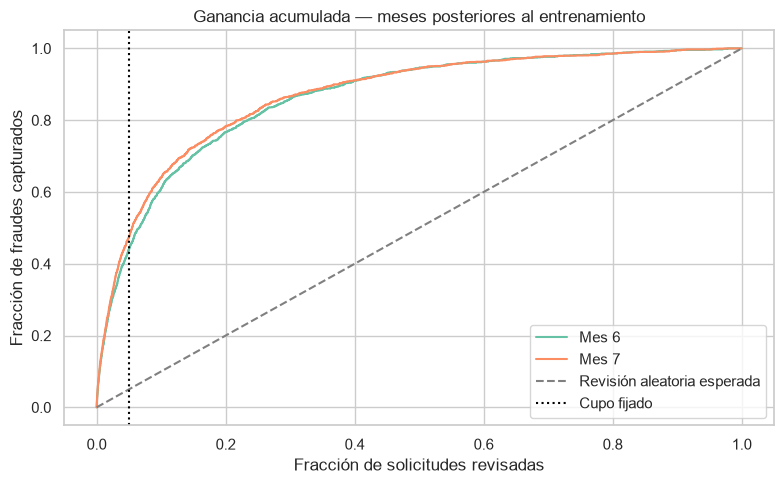

In [20]:
# 20. Ganancia acumulada en cada mes de prueba
fig, ax = plt.subplots(figsize=(8, 5))
for mes, grupo in ranking_prueba.groupby('month'):
    fraccion = np.arange(1, len(grupo) + 1) / len(grupo)
    captura = grupo['fraude_real'].cumsum() / grupo['fraude_real'].sum()
    ax.plot(np.r_[0, fraccion], np.r_[0, captura], label=f'Mes {mes}')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Revisión aleatoria esperada')
ax.axvline(FRACCION_REVISION, linestyle=':', color='black', label='Cupo fijado')
ax.set(xlabel='Fracción de solicitudes revisadas', ylabel='Fracción de fraudes capturados',
       title='Ganancia acumulada — meses posteriores al entrenamiento')
ax.legend()
plt.tight_layout()
plt.show()


## Capacidad de revisión
Supongamos que cada revisión toma **10 minutos**. Es un supuesto de planificación, no una duración medida por BAF. Con él convertimos solicitudes en horas de trabajo y comparamos capacidades.

No estimamos dinero ahorrado: el límite de crédito propuesto no equivale a pérdida confirmada, y detectar un fraude no demuestra que se haya evitado. Para monetizar resultados se necesitarían pérdidas observadas, recuperaciones y costos de revisión.


In [21]:
# 21. Escenarios ilustrativos; el cupo principal se mantiene en 5 %
MINUTOS_POR_REVISION = 10
escenarios = []
for fraccion in [0.01, 0.03, 0.05, 0.10]:
    ranking_escenario = crear_ranking(df.loc[idx_test, 'solicitud_id'], df.loc[idx_test, 'month'],
                                       prob_test, y_test, fraccion=fraccion)
    resumen = resumir_revision(ranking_escenario)
    escenarios.append({'fraccion_revision': fraccion, **resumen,
                        'horas_revision': resumen['revisiones'] * MINUTOS_POR_REVISION / 60})
escenarios = pd.DataFrame(escenarios)
display(escenarios[['fraccion_revision', 'revisiones', 'fraudes_capturados', 'legitimas_revisadas',
                    'precision_top', 'recall_top', 'fpr_top', 'horas_revision']].round(4))


,fraccion_revision,revisiones,fraudes_capturados,legitimas_revisadas,precision_top,recall_top,fpr_top,horas_revision
0,0.01,2051,508,1543,0.2477,0.1765,0.0076,341.8333
1,0.03,6152,1016,5136,0.1651,0.3530,0.0254,1025.3333
2,0.05,10252,1315,8937,0.1283,0.4569,0.0442,1708.6667
3,0.10,20502,1798,18704,0.0877,0.6247,0.0925,3417.0000


Los escenarios muestran el intercambio entre carga y captura. No se elige un nuevo cupo mirando la prueba; un cambio de política debe justificarse con capacidad disponible y nueva validación.

## Auditoría de errores por grupos
BAF permite estudiar diferencias de errores entre grupos. Usaremos la misma política del 5 % por mes para todos y luego mediremos su efecto en rangos de edad, ingreso y empleo. No asignaremos umbrales distintos por edad o ingreso.

La **FPR por grupo** divide las legítimas revisadas entre todas las legítimas de ese grupo. El **recall por grupo** divide los fraudes capturados entre todos los fraudes del grupo. Reportamos denominadores para evitar conclusiones basadas en pocos casos. Es una auditoría descriptiva, no una certificación de equidad.


,atributo,grupo,solicitudes,fraudes,legitimas,fraudes_capturados,legitimas_revisadas,tasa_revision,recall,fpr
0,grupo_edad,50 o más,33779,989,32790,545,2744,0.0974,0.5511,0.0837
1,grupo_edad,Menor de 50,171232,1889,169343,770,6193,0.0407,0.4076,0.0366
2,grupo_ingreso,Deciles hasta 0.3,42405,309,42096,127,1186,0.0310,0.4110,0.0282
3,grupo_ingreso,Deciles 0.4–0.6,24816,230,24586,99,826,0.0373,0.4304,0.0336
4,grupo_ingreso,Deciles 0.7–0.9,137790,2339,135451,1089,6925,0.0582,0.4656,0.0511
5,employment_status,CA,158709,2413,156296,1128,7222,0.0526,0.4675,0.0462
6,employment_status,CB,22838,216,22622,84,965,0.0459,0.3889,0.0427
7,employment_status,CC,6511,202,6309,90,460,0.0845,0.4455,0.0729
8,employment_status,CD,4517,13,4504,4,100,0.0230,0.3077,0.0222
9,employment_status,CE,4550,15,4535,5,87,0.0202,0.3333,0.0192


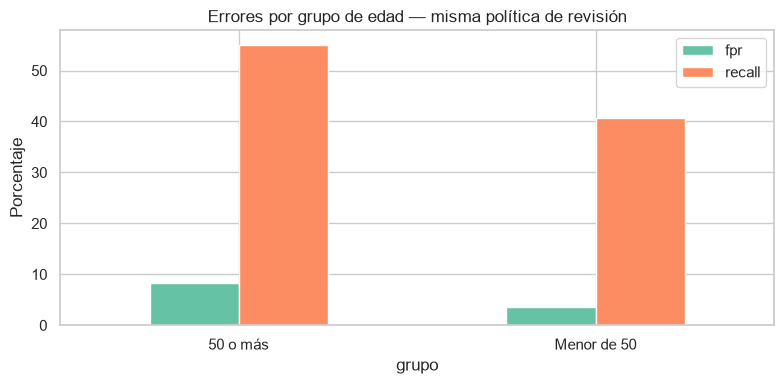

In [22]:
# 22. Auditoría con etiquetas de prueba, sin cambiar el modelo
auditoria = ranking_prueba.merge(df[['solicitud_id'] + AUDITORIA], on='solicitud_id',
                                 how='left', validate='one_to_one')
auditoria['grupo_edad'] = np.where(auditoria['customer_age'] < 50, 'Menor de 50', '50 o más')
auditoria['grupo_ingreso'] = pd.cut(auditoria['income'], bins=[0, 0.3, 0.6, 1],
                                   labels=['Deciles hasta 0.3', 'Deciles 0.4–0.6', 'Deciles 0.7–0.9'])
tablas_auditoria = []
for atributo in ['grupo_edad', 'grupo_ingreso', 'employment_status']:
    for grupo, datos in auditoria.groupby(atributo, observed=True, dropna=False):
        n_fraude = int(datos['fraude_real'].sum())
        n_legitimas = int((datos['fraude_real'] == 0).sum())
        tp = int(((datos['fraude_real'] == 1) & datos['revisar']).sum())
        fp = int(((datos['fraude_real'] == 0) & datos['revisar']).sum())
        tablas_auditoria.append({'atributo': atributo, 'grupo': str(grupo), 'solicitudes': len(datos),
            'fraudes': n_fraude, 'legitimas': n_legitimas, 'fraudes_capturados': tp,
            'legitimas_revisadas': fp, 'tasa_revision': datos['revisar'].mean(),
            'recall': tp / n_fraude if n_fraude else np.nan,
            'fpr': fp / n_legitimas if n_legitimas else np.nan})

tabla_auditoria = pd.DataFrame(tablas_auditoria)
display(tabla_auditoria.round(4))
edad = tabla_auditoria[tabla_auditoria['atributo'] == 'grupo_edad'].set_index('grupo')
edad[['fpr', 'recall']].mul(100).plot.bar(rot=0, figsize=(8, 4),
    title='Errores por grupo de edad — misma política de revisión', ylabel='Porcentaje')
plt.tight_layout()
plt.show()


In [23]:
# 23. Respuesta ejecutiva calculada
evidencia = (metricas_test['roc_auc'] > 0.5 and metricas_test['average_precision'] > y_test.mean()
             and resumen_prueba['lift_top'] > 1)
diagnostico = ('El modelo concentra más fraude que una revisión sin señal predictiva.' if evidencia
               else 'Los resultados no respaldan recomendar la priorización con este modelo.')
display(Markdown(f'''### Respuesta a la Gerencia de NovaFin
**Modelo elegido:** {nombre_elegido}, ajustado con **{len(X_train):,} solicitudes** de los meses 0–4.
{diagnostico}

En los meses 6–7 se evaluaron **{len(X_test):,} solicitudes** con tasa de fraude de **{y_test.mean():.2%}**.
ROC-AUC = **{metricas_test['roc_auc']:.3f}** y AP = **{metricas_test['average_precision']:.3f}**.

La política del **{FRACCION_REVISION:.0%} por mes** selecciona **{resumen_prueba['revisiones']:,} revisiones**,
que concentran **{resumen_prueba['fraudes_capturados']:,} de {resumen_prueba['fraudes_totales']:,} fraudes**
(Recall@K = **{resumen_prueba['recall_top']:.1%}**; Precision@K = **{resumen_prueba['precision_top']:.1%}**).
También envía a revisión **{resumen_prueba['legitimas_revisadas']:,} solicitudes legítimas**.
Lift@K = **{resumen_prueba['lift_top']:.2f}**; la revisión aleatoria con los mismos cupos capturaría
en promedio **{resumen_prueba['fraudes_esperados_azar']:.1f} fraudes**.

La propuesta didáctica es entregar esta cola al analista y medir su carga, sus errores y diferencias entre grupos.
No se ha demostrado pérdida evitada ni calibración. BAF es sintético; tampoco conocemos fechas de maduración
de etiquetas para simular una implantación en vivo. Estas cifras corresponden a solicitudes, no a intenciones personales.
'''))


### Respuesta a la Gerencia de NovaFin
**Modelo elegido:** Regresión logística, ajustado con **100,000 solicitudes** de los meses 0–4.
El modelo concentra más fraude que una revisión sin señal predictiva.

En los meses 6–7 se evaluaron **205,011 solicitudes** con tasa de fraude de **1.40%**.
ROC-AUC = **0.871** y AP = **0.151**.

La política del **5% por mes** selecciona **10,252 revisiones**,
que concentran **1,315 de 2,878 fraudes**
(Recall@K = **45.7%**; Precision@K = **12.8%**).
También envía a revisión **8,937 solicitudes legítimas**.
Lift@K = **9.14**; la revisión aleatoria con los mismos cupos capturaría
en promedio **143.9 fraudes**.

La propuesta didáctica es entregar esta cola al analista y medir su carga, sus errores y diferencias entre grupos.
No se ha demostrado pérdida evitada ni calibración. BAF es sintético; tampoco conocemos fechas de maduración
de etiquetas para simular una implantación en vivo. Estas cifras corresponden a solicitudes, no a intenciones personales.


## Predicción de una solicitud individual
Seleccionamos una observación del conjunto de prueba. Es una solicitud **sintética de BAF** que no se utilizó para ajustar ni elegir el modelo. Su etiqueta se muestra después de predecir únicamente para ilustrar la evaluación.

Una puntuación que supere el umbral de validación indica revisar; una puntuación inferior significa que no activa esa referencia, no que se haya demostrado ausencia de fraude. El lugar en una cola con cupo se conoce al comparar todas las solicitudes del lote.


In [24]:
# 24. Puntuar una solicitud con las mismas transformaciones
solicitud_ejemplo = df.loc[[idx_test[0]]]
entrada_ejemplo = preparar_variables(solicitud_ejemplo)
riesgo_ejemplo = float(predecir_por_lotes(modelo_elegido, entrada_ejemplo)[0])
display(solicitud_ejemplo[['solicitud_id', 'source', 'name_email_similarity', 'phone_mobile_valid',
                          'session_length_in_minutes', 'proposed_credit_limit']])
print(f'Puntuación estimada: {riesgo_ejemplo:.4f}')
print('Recomendación por umbral:', 'Revisión adicional' if riesgo_ejemplo >= umbral_validacion
      else 'No activa la referencia de revisión')
print('Etiqueta conocida para evaluar este ejemplo:', int(solicitud_ejemplo[OBJETIVO].iloc[0]))


,solicitud_id,source,name_email_similarity,phone_mobile_valid,session_length_in_minutes,proposed_credit_limit
794989,794990,INTERNET,0.536292,1,1.842079,500.0


Puntuación estimada: 0.0006
Recomendación por umbral: No activa la referencia de revisión
Etiqueta conocida para evaluar este ejemplo: 0


## Guardar y reutilizar el modelo
Guardamos **el mismo modelo que acabamos de evaluar**, sus reglas de preparación, columnas y umbral. No lo reajustamos con la prueba: así se mantiene la correspondencia entre el artefacto y las métricas reportadas.

El pipeline contiene imputación, codificación, escalado y clasificador. La función determinista `preparar_variables` debe aplicarse antes de invocarlo; la guardamos también como archivo Python para que el contrato de limpieza acompañe al artefacto. No publicamos un servicio bancario: este es un entregable de laboratorio.


In [25]:
# 25. Exportar métricas, ranking y artefacto reproducible
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)
artefacto = {'pipeline': modelo_elegido, 'modelo': nombre_elegido,
    'reglas_preparacion': REGLAS_PREPARACION, 'columnas_entrada': COLUMNAS_ENTRADA,
    'umbral_validacion': umbral_validacion, 'fraccion_revision': FRACCION_REVISION,
    'meses_entrenamiento': MESES_TRAIN, 'meses_validacion': MESES_VAL,
    'meses_prueba': MESES_TEST, 'filas_ajuste': len(X_train),
    'sklearn_version': sklearn.__version__, 'uso': 'laboratorio_BAF_no_produccion',
    'metricas_prueba': metricas_test, 'revision_prueba': resumen_prueba}
joblib.dump(artefacto, RUTA_SALIDA / 'modelo_fraude_financiero.joblib')

# Exportamos la función de limpieza sin un valor por defecto dependiente del notebook.
import inspect
codigo_preparacion = inspect.getsource(preparar_variables).replace(
    'reglas=REGLAS_PREPARACION', 'reglas')
(RUTA_SALIDA / 'preparacion_baf.py').write_text(
    'import numpy as np\nimport pandas as pd\n\n' + codigo_preparacion, encoding='utf-8')

comparacion.to_csv(RUTA_SALIDA / 'comparacion_validacion.csv', encoding='utf-8-sig')
comparacion_umbrales.to_csv(RUTA_SALIDA / 'metricas_umbrales_prueba.csv', encoding='utf-8-sig')
resultados_mes.to_csv(RUTA_SALIDA / 'revision_por_mes.csv', encoding='utf-8-sig')
escenarios.to_csv(RUTA_SALIDA / 'escenarios_capacidad.csv', index=False, encoding='utf-8-sig')
tabla_auditoria.to_csv(RUTA_SALIDA / 'auditoria_grupos.csv', index=False, encoding='utf-8-sig')
ranking_prueba.to_csv(RUTA_SALIDA / 'evaluacion_ranking_prueba.csv', index=False, encoding='utf-8-sig')
cola_didactica = ranking_prueba.loc[ranking_prueba['revisar'],
    ['solicitud_id', 'month', 'riesgo_estimado', 'prioridad_mes']].copy()
cola_didactica['accion'] = 'Revision adicional por analista; simulacion BAF'
cola_didactica.to_csv(RUTA_SALIDA / 'cola_revision_didactica.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({'solicitud_id': df.loc[idx_train, 'solicitud_id']}).to_csv(
    RUTA_SALIDA / 'ids_entrenamiento.csv', index=False)
resumen_ejecucion = {
    'fuente': 'https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022',
    'archivo': str(ruta_base), 'sha256_base': hashlib.sha256(ruta_base.read_bytes()).hexdigest(),
    'filas_base': len(df), 'filas_entrenamiento': len(X_train),
    'filas_validacion': len(X_val), 'filas_prueba': len(X_test),
    'semilla': SEMILLA, 'modelo': nombre_elegido, 'umbral_validacion': umbral_validacion,
    'fraccion_revision': FRACCION_REVISION, 'metricas_prueba': metricas_test,
    'revision_prueba': resumen_prueba,
    'versiones': {'python': platform.python_version(), 'pandas': pd.__version__,
                 'numpy': np.__version__, 'sklearn': sklearn.__version__}
}
(RUTA_SALIDA / 'resumen_ejecucion.json').write_text(
    json.dumps(resumen_ejecucion, indent=2, ensure_ascii=False), encoding='utf-8')
print('Entregables guardados en:', RUTA_SALIDA.resolve())


Entregables guardados en: D:\Clases\NEWHORIZONS\Python\Ejercicios\exports\fraude_financiero


In [30]:
# 26. Verificar la recarga, la preparación exportada y la correspondencia del ranking
import importlib.util
especificacion = importlib.util.spec_from_file_location('preparacion_baf', RUTA_SALIDA / 'preparacion_baf.py')
modulo_preparacion = importlib.util.module_from_spec(especificacion)
especificacion.loader.exec_module(modulo_preparacion)
cargado = joblib.load(RUTA_SALIDA / 'modelo_fraude_financiero.joblib')  # Solo artefactos propios/de confianza
entrada_recargada = modulo_preparacion.preparar_variables(solicitud_ejemplo, cargado['reglas_preparacion'])
np.testing.assert_allclose(modelo_elegido.predict_proba(entrada_ejemplo),
                           cargado['pipeline'].predict_proba(entrada_recargada))

print('Recarga correcta; preparación, puntuaciones y cupos verificados.')


Recarga correcta; preparación, puntuaciones y cupos verificados.


## Aplicar a otro lote de laboratorio: sección opcional
Si dispones de un lote sintético independiente, guárdalo como `solicitudes_nuevas.csv` en la carpeta de datos. Debe contener `solicitud_id` único, `month` y las 24 columnas de entrada, sin `fraud_bool`. No reutilices el archivo Base como si fueran solicitudes futuras; el ranking de prueba ya está exportado.

La ausencia de etiquetas impide evaluar precisión o recall. El mes identifica el lote para aplicar el cupo; no entra al modelo. Para operar antes de terminar un mes se necesitaría una política por lote diario o un umbral con monitoreo de volumen.


In [31]:
# 27. Puntuar un lote opcional sin etiquetas
ruta_nuevas = RUTA_DATOS / 'solicitudes_nuevas.csv'
if ruta_nuevas.exists():
    nuevas = pd.read_csv(ruta_nuevas)
    if nuevas.empty or not {'solicitud_id', 'month'}.issubset(nuevas.columns) or OBJETIVO in nuevas:
        raise ValueError('Se requiere un lote no vacío con solicitud_id, month y sin fraud_bool.')
    if nuevas['solicitud_id'].isna().any() or nuevas['solicitud_id'].duplicated().any() or nuevas['month'].isna().any():
        raise ValueError('IDs únicos y no nulos; mes de lote no nulo.')
    if nuevas['solicitud_id'].astype(str).isin(df['solicitud_id'].astype(str)).any():
        raise ValueError('Usa IDs de lote nuevos para no confundirlos con las solicitudes de Base.')
    entrada_nueva = modulo_preparacion.preparar_variables(nuevas, cargado['reglas_preparacion'])
    prob_nueva = predecir_por_lotes(cargado['pipeline'], entrada_nueva)
    ranking_nuevo = crear_ranking(nuevas['solicitud_id'], nuevas['month'], prob_nueva,
                                   fraccion=cargado['fraccion_revision'])
    ranking_nuevo.to_csv(RUTA_SALIDA / 'ranking_nuevas_solicitudes.csv', index=False, encoding='utf-8-sig')
    display(ranking_nuevo.head(10))
else:
    print('No hay lote nuevo. La ejecución del caso y la evaluación histórica están completas.')


No hay lote nuevo. La ejecución del caso y la evaluación histórica están completas.


## Cierre: recomendación y entregables del alumno
La salida es una **lista priorizada de solicitudes que requieren revisión**. Para una solicitud aislada entregamos su puntuación y una referencia de revisión; no una acusación ni una aprobación de crédito.

Expón los resultados al equipo de Prevención de Fraude:
1. Presenta tres hallazgos del EDA con cantidades y tasas.
2. Justifica el modelo elegido en validación y explica sus errores en los meses de prueba.
3. Informa cuántos casos caben en el cupo, cuántos fraudes concentra y cuántas solicitudes legítimas revisa.
4. Explica las diferencias de FPR y recall entre grupos, indicando sus denominadores.
5. Delimita lo demostrado: datos sintéticos, etiquetas maduras retrospectivas, falta de fechas de confirmación y ausencia de pérdidas observadas.

### Rúbrica sugerida
| Criterio | Puntos |
| --- | ---: |
| Problema, unidad de análisis y momento de predicción | 15 |
| Calidad de datos, marcadores de ausencia y separación temporal | 20 |
| EDA, agrupaciones y visualizaciones interpretadas | 20 |
| Comparación, evaluación y reproducibilidad del modelo | 25 |
| Capacidad de revisión, auditoría y recomendación ejecutiva | 20 |
| **Total** | **100** |

### Extensiones opcionales
Evaluar una variante de BAF como experimento separado; estudiar calibración con datos reservados; comparar periodos con validación temporal; o analizar estabilidad por remuestreo. Si inicias una nueva búsqueda de modelos, conserva otra prueba independiente. Entrenar con BAF prepara al alumno para experimentar: un modelo operativo requeriría datos del banco y una evaluación propia.
